# UE02 - Korrelationsanalyse cont. und Regression: Modellanpassung

Nachdem wir uns in UE01 schon mit der grundlegenden Funktionalität der Bibliothek [matplotlib](https://matplotlib.org/) vertraut gemacht haben und die Korrelationsanalyse per [NumPy corrcoef()](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) angeschnitten haben, werden wir uns in dieser Übung mit komplexeren Konzepten von matplotlib wie [Subplots](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html) und der Modellanpassung per Regression beschäftigten.

Eine komfortable Implementierung des Konzepts der linearen Regression unterschiedlicher Ordnungen bietet die NumPy-Klasse [Polynomial](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html).
Weitere Infos zur Verwendung dieser Klasse könnt Ihr [dieser Übersichtsseite](https://numpy.org/doc/stable/reference/routines.polynomials.html) sowie der Dokumentation zur Methode [Polynomial.fit()](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.fit.html) entnehmen.

Zur Lösung der Problemstellungen und für weitere Erklärungen zu den in diesem Notebook verwendeten Formeln empfehle ich darüber hinaus das Skript zur Vorlesung Daten und Statistik von Dr. Stefan Wegenkittl.
Für diese Übung sind dabei insbesondere die Seiten 12-19 wichtig.

In [2]:
# Todo: Importstatements!
import numpy as np
import matplotlib.pyplot as plt

## UE02.a)
Korrelationsanalyse der Merkmale des Datensatzes correlation.csv.
<ol>
    <li>Platziere die Datei <tt>correlation.csv</tt> aus dem Moodlekurs im Ordner <tt>data/</tt>. Lade anschließend <tt>data/correlation.csv</tt> in die Variable <tt>correlation</tt>.
        <br>
        <strong>Vorsicht</strong>: Sind Daten in Textformat (<tt>.txt</tt>, <tt>.csv</tt>, etc.) abgelegt, stellt NumPy eigene Funktionen (bspw. <a href="https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html">loadtxt()</a> oder <a href="https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html">genfromtxt()</a> für das Laden des Inhalts in NumPy-Arrays bereit.
    </li>
    <li>Erstelle Scatterplots (oder eine Figure mit entsprechend vielen Subplots), die den ersten Spaltenvektor (X-Achse) gegen die restlichen Spaltenvektoren (Y-Achse) stellen, um damit die Korrelationen der Spalten zu untersuchen.</li>
    <li>Berechne die Korrelationskoeffizienten $r_{xy} = \cfrac{s_{xy}}{s_x \cdot s_y}$ des ersten Spaltenvektors in Bezug zu den restlichen Spalten in <tt>correlation</tt> und platziere diese Information formattiert im dazugehörigen Scatter-, bzw. Subplot.</li>
    <li>Nicht vergessen: entsprechende Beschriftungen für den/die Titel sowie die X-, und Y-Achse(n).</li>
    <li>Interpretiere das Ergebnis in Kommentarform oder als Markdownzelle.</li>
</ol>

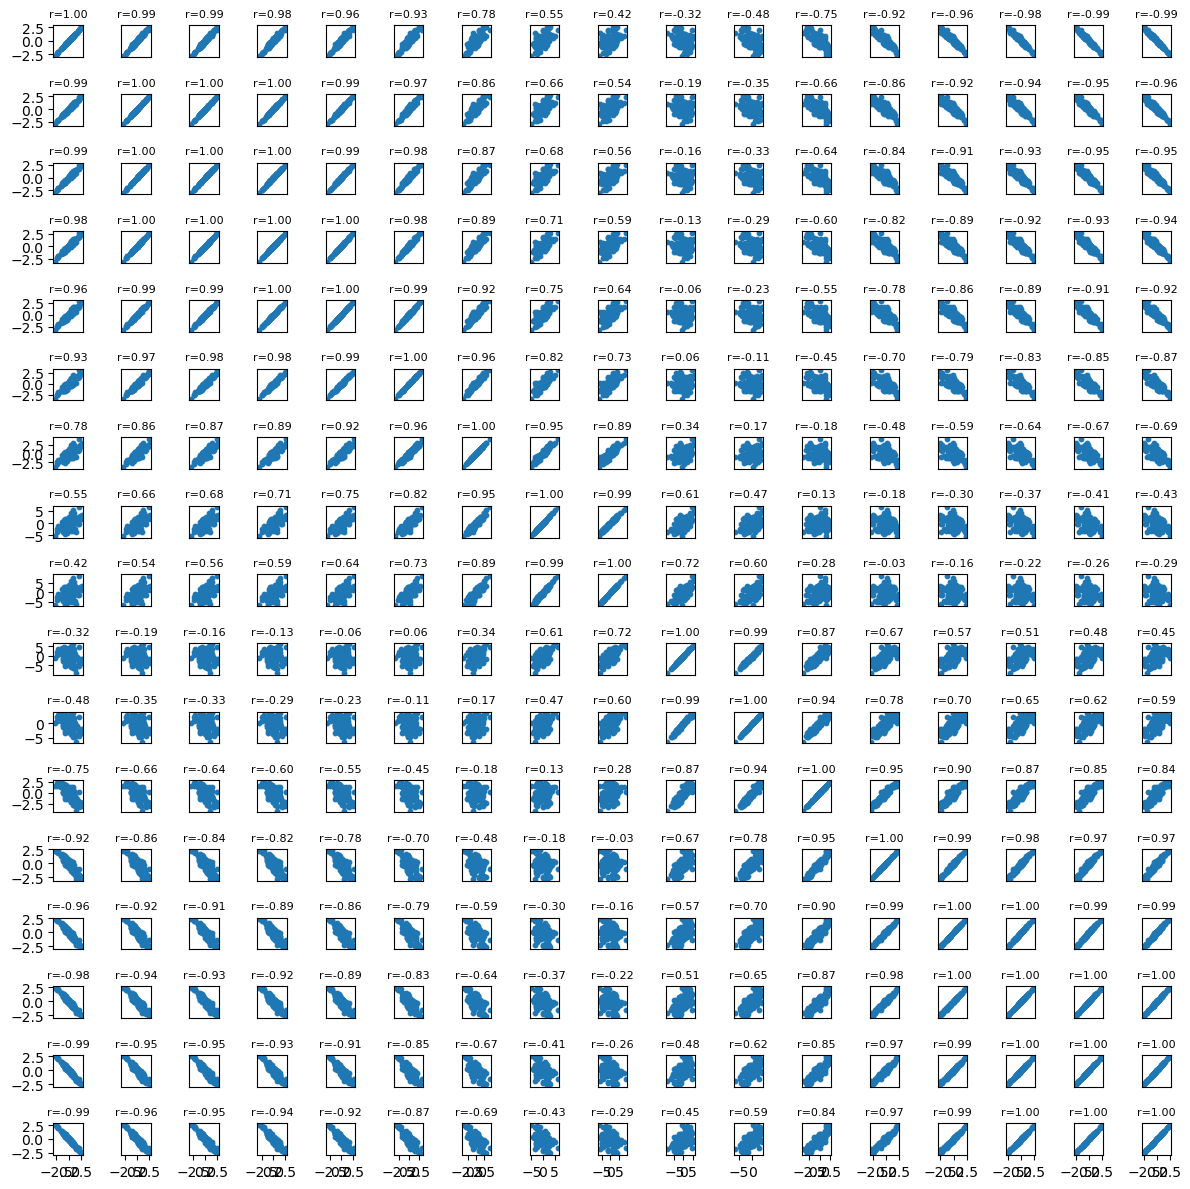

In [5]:
# Todo: UE02.a)
# Load data
correlation = np.loadtxt("correlation.csv", delimiter=",")

# Number of features
n = correlation.shape[1]

# Create subplots
fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        
        x = correlation[:, j]
        y = correlation[:, i]
        
        ax.scatter(x, y, s=10)
        
        # Correlation coefficient
        r = np.corrcoef(x, y)[0, 1]
        
        ax.set_title(f"r={r:.2f}", fontsize=8)
        
        # Cleaner layout
        if i != n - 1:
            ax.set_xticks([])
        if j != 0:
            ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
# Gerne auch

In [ ]:
# in mehreren

In [ ]:
# Zellen.

## UE02.b)
Erweiterung von UE02.a) um die lineare Regression
<ol>
    <li>Berechne für alle (Sub-)Plots aus UE02.a) den quadrierten Korrelationskoeffizienten $r_{xy}^{2} = \left(\cfrac{s_{xy}}{s_x \cdot s_y}\right)^2$.</li>
    <li>Errechne für all jene (Sub-)Plots, für die  $r_{xy}^{2} >= 0.5$ gilt, die lineare Regression erster Ordnung.</li>
    <li>Zeichne die lineare Regression erster Ordnung in die betreffenden (Sub-)Plots ein.</li>
    <li>Nicht vergessen: entsprechende Beschriftungen für den/die Titel sowie die X-, und Y-Achse(n).</li>
    <li>Interpretiere das Ergebnis in Kommentarform oder als Markdownzelle.</li>
</ol>

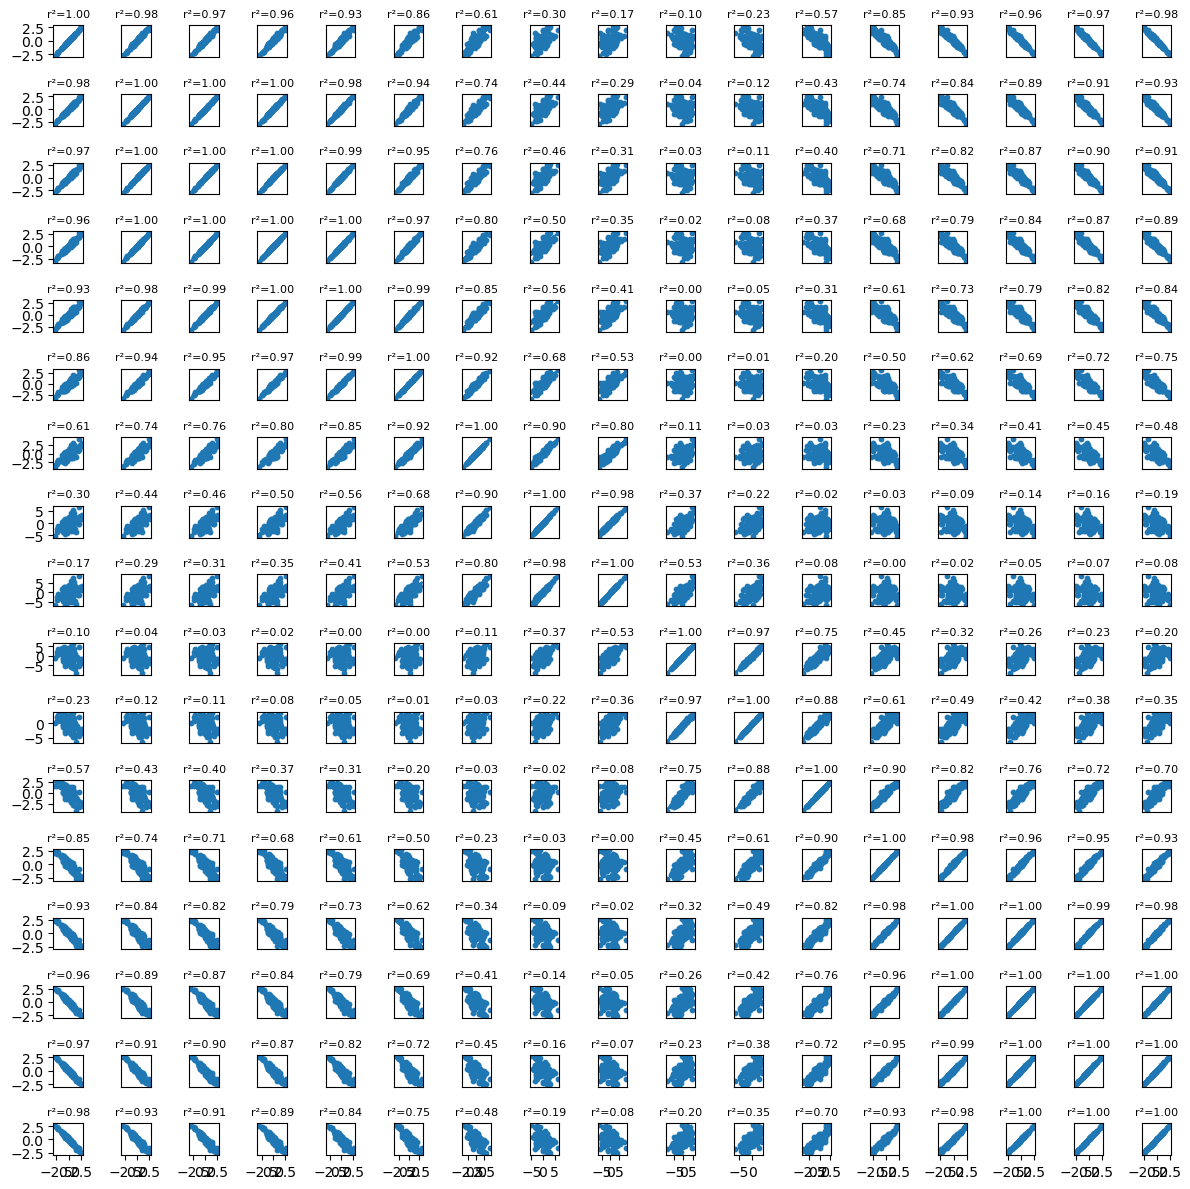

In [6]:
# Todo: UE02.b)
fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        
        x = correlation[:, j]
        y = correlation[:, i]
        
        ax.scatter(x, y, s=10)
        
        # Correlation
        r = np.corrcoef(x, y)[0, 1]
        r2 = r**2
        
        ax.set_title(f"r²={r2:.2f}", fontsize=8)
        
        # Linear regression if strong correlation
        if r2 >= 0.5:
            coeffs = np.polyfit(x, y, 1)
            y_fit = np.polyval(coeffs, x)
            ax.plot(x, y_fit)
        
        if i != n - 1:
            ax.set_xticks([])
        if j != 0:
            ax.set_yticks([])

plt.tight_layout()
plt.show()

## UE02.c)
Berechnung und Plotting linearer Regressionskurven unterschiedlicher Ordnung für die Daten in `regression.npy` mit anschließender visueller Analyse der Ergebnisse.

<ol>
    <li>Platziere die Datei <tt>regression.npy</tt> aus dem Moodlekurs im Ordner <tt>data/</tt>. Lade anschließend <tt>data/regression.npy</tt> in die Variable <tt>regression</tt>.</li>
    <li>Extrahiere die erste Spalte des Arrays in <tt>regression</tt> als x, die zweite Spalte des Arrays als y.</li>
    <li>Plotte y über x in einem Scatterplot mit entsprechenden Achsenbeschriftungen und einem Titel.</li>
    <li>Berechne den Korrelationskoeffizienten zwischen x und y und gib diesen formattiert aus.</li>
    <li>Berechne die lineare Regression 1. bis 12. Ordnung.</li>
    <li>Generiere 12 (Sub-)Plots, die sowohl die Daten in x und y als Scatterplot, als auch jeweils eine lineare Regression bestimmter Ordnung übersichtlich darstellen.</li>
    <li>Interpretiere das Ergebnis und begründe als Kommentar oder in einer Markdownzelle, welche Regressionskurve aus deiner Sicht die Daten am Besten beschreibt.</li>
</ol>

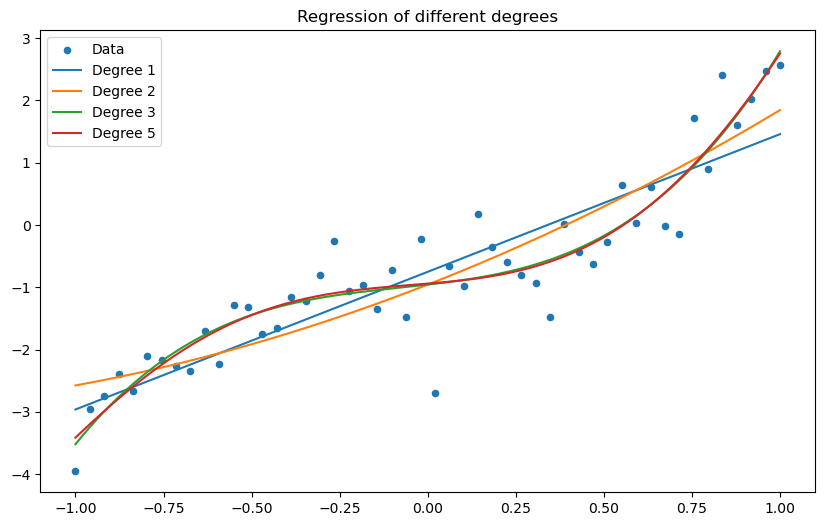

In [8]:
# Todo: UE02.c)
# Load data
regression = np.load("regression.npy")

x = regression[:, 0]
y = regression[:, 1]

degrees = [1, 2, 3, 5]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data", s=20)

x_fit = np.linspace(min(x), max(x), 200)

for d in degrees:
    coeffs = np.polyfit(x, y, d)
    y_fit = np.polyval(coeffs, x_fit)
    plt.plot(x_fit, y_fit, label=f"Degree {d}")

plt.legend()
plt.title("Regression of different degrees")
plt.show()

## UE02.d)
Erweiterung von UE02.c) um die Berechnung der Summe der Residuenquadrate $SQR$ <i>(engl. least squares residuals, $RSS$)</i> und die Berechnung des korrigierten Bestimmtheitsmaßes

$\bar{r}_{xy}^{2} = \cfrac{\hat{s}^2}{s_y^2}= 1 - \cfrac{\cfrac{1}{n-k}\;\sum_{i=1}^{n}\;(y_i - \hat{y}_i)^2}{\cfrac{1}{n-1}\;\sum_{i=1}^{n}\;(y_i - \bar{y}_i)^2}$

<ol>
    <li>Erweitere UE02.c) so, dass für alle Regressionskurven die Summe der Residuenquadrate im (Sub-)Plot dargestellt wird.<br>
        <strong>Tipp:</strong> Parameter <tt>full=True</tt> beim Aufruf der Methode <a href="https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.fit.html">Polynomial.fit()</a> setzen und das return value <tt>resid</tt> verwenden.
    </li>
    <li>Interpretiere das Ergebnis und nimm dabei speziell Bezug auf deine Erkenntnisse aus UE02.c). Deckt sich der Eindruck des visuellen "best fit" mit dem numerischen Ergebnis?</li>
    <li>Zuletzt ist das korrigierte Bestimmtheitsmaß $\bar{r}_{xy}^{2}$ für alle Regressionskurven zu rechnen und ebenfalls in allen (Sub-)Plots darzustellen.</li>
    <li>Entscheide nun final anhand der korrigierten Bestimmtheitsmaße, welche Regressionskurve einen adäquaten Kompromiss zwischen Modellkomplexität und fit auf die Daten bietet.</li>
</ol>

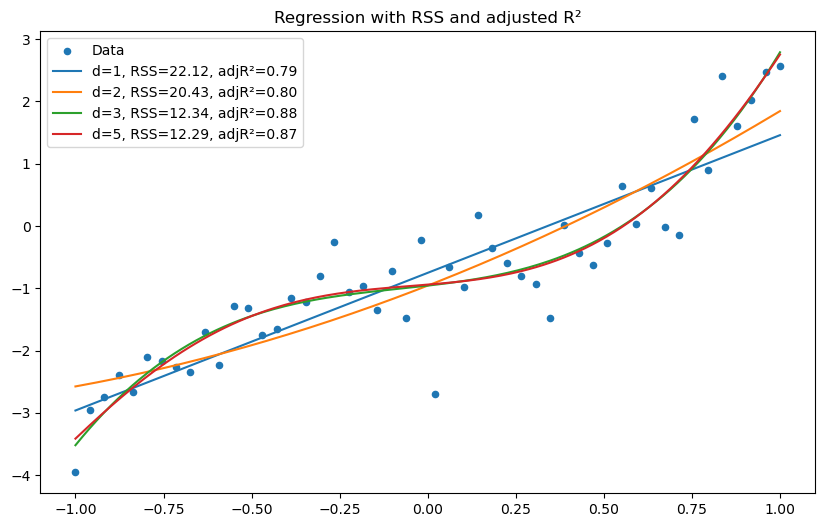

In [9]:
# Todo: UE02.d)
n = len(y)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=20, label="Data")

for d in degrees:
    coeffs = np.polyfit(x, y, d)
    y_hat = np.polyval(coeffs, x)
    
    # RSS (Residual Sum of Squares)
    rss = np.sum((y - y_hat) ** 2)
    
    # Total variance
    y_mean = np.mean(y)
    tss = np.sum((y - y_mean) ** 2)
    
    # Adjusted R²
    k = d + 1  # number of parameters
    r2_adj = 1 - (rss / (n - k)) / (tss / (n - 1))
    
    # Smooth curve
    x_fit = np.linspace(min(x), max(x), 200)
    y_fit = np.polyval(coeffs, x_fit)
    
    plt.plot(x_fit, y_fit, label=f"d={d}, RSS={rss:.2f}, adjR²={r2_adj:.2f}")

plt.legend()
plt.title("Regression with RSS and adjusted R²")
plt.show()